#Analysis Project
#**Predicting Mobile Phone Prices Using Random Forest Regression**
#Olena Hrytsyk
#Data: 05/08/2025

This project explores the use of a machine learning model to predict the launch price of mobile phones in the United States using dataset Mobiles Dataset (2025)

Imports the necessary Python libraries

In [153]:
import re
import seaborn as sns
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use("default")

Downloads the dataset using kagglehub by specifying the dataset name.Read and display the dataset.

In [154]:
path = kagglehub.dataset_download("abdulmalik1518/mobiles-dataset-2025")
file = "Mobiles Dataset (2025).csv"

df = pd.read_csv(
    "/".join([path, file]),
    encoding="ISO-8859-1")
df.head()

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
0,Apple,iPhone 16 128GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 224,999","INR 79,999","CNY 5,799",USD 799,"AED 2,799",2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 234,999","INR 84,999","CNY 6,099",USD 849,"AED 2,999",2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 244,999","INR 89,999","CNY 6,499",USD 899,"AED 3,199",2024
3,Apple,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 249,999","INR 89,999","CNY 6,199",USD 899,"AED 3,199",2024
4,Apple,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 259,999","INR 94,999","CNY 6,499",USD 949,"AED 3,399",2024


Displays the shape (rows, columns) of the dataset.

In [155]:
df.shape

(930, 15)

Displays a summary of dataset.

In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930 entries, 0 to 929
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company Name               930 non-null    object
 1   Model Name                 930 non-null    object
 2   Mobile Weight              930 non-null    object
 3   RAM                        930 non-null    object
 4   Front Camera               930 non-null    object
 5   Back Camera                930 non-null    object
 6   Processor                  930 non-null    object
 7   Battery Capacity           930 non-null    object
 8   Screen Size                930 non-null    object
 9   Launched Price (Pakistan)  930 non-null    object
 10  Launched Price (India)     930 non-null    object
 11  Launched Price (China)     930 non-null    object
 12  Launched Price (USA)       930 non-null    object
 13  Launched Price (Dubai)     930 non-null    object
 14  Launched Y

Checks for duplicate rows in the dataset.

In [157]:
df.duplicated().sum()

np.int64(15)

Drop the duplicate.

In [158]:
df=df.drop_duplicates()

In [159]:
df.duplicated().sum()

np.int64(0)

Replace spaces and parentheses in columns with underscores (and clean up formatting)

In [160]:
df.columns = df.columns.str.replace(' ', '_').str.replace('(', '').str.replace(')', '').str.strip()
df.head()

,Company_Name,Model_Name,Mobile_Weight,RAM,Front_Camera,Back_Camera,Processor,Battery_Capacity,Screen_Size,Launched_Price_Pakistan,Launched_Price_India,Launched_Price_China,Launched_Price_USA,Launched_Price_Dubai,Launched_Year
0,Apple,iPhone 16 128GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 224,999","INR 79,999","CNY 5,799",USD 799,"AED 2,799",2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 234,999","INR 84,999","CNY 6,099",USD 849,"AED 2,999",2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 244,999","INR 89,999","CNY 6,499",USD 899,"AED 3,199",2024
3,Apple,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 249,999","INR 89,999","CNY 6,199",USD 899,"AED 3,199",2024
4,Apple,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 259,999","INR 94,999","CNY 6,499",USD 949,"AED 3,399",2024


Clean price data from multiple columns that contain both currency symbols and numbers (like "USD 1,299" or "PKR 224,999").

In [161]:
currencies = ["Launched_Price_Pakistan",	"Launched_Price_India",	"Launched_Price_China",	"Launched_Price_USA",	"Launched_Price_Dubai"]

for cur in currencies:

    df[cur] = df[cur].astype(str).str.extract(r"(\d[\d,]*\.\d+|\d[\d,]*)")[0]
    df[cur] = df[cur].str.replace(",", "", regex=True)
    df[cur] = pd.to_numeric(df[cur], errors='coerce')

 Clean and convert feature columns: remove units (GB, g, inches, mAh), strip text, and convert to numeric values.

In [162]:
df['RAM'] = df['RAM'].astype(str).str.replace("GB", "").str.strip()
df['RAM'] = pd.to_numeric(df['RAM'], errors='coerce')
df['Mobile_Weight'] = df['Mobile_Weight'].astype(str).str.replace("g", "").str.strip()
df['Mobile_Weight'] = pd.to_numeric(df['Mobile_Weight'], errors='coerce')
df['Screen_Size'] = df['Screen_Size'].astype(str).str.replace("inches", "").str.strip()
df['Screen_Size'] = pd.to_numeric(df['Screen_Size'], errors='coerce')
df["Battery_Capacity"] = df["Battery_Capacity"].str.replace(r"[^\d]", "", regex=True)
df["Battery_Capacity"] = pd.to_numeric(df["Battery_Capacity"], errors='coerce')

df

,Company_Name,Model_Name,Mobile_Weight,RAM,Front_Camera,Back_Camera,Processor,Battery_Capacity,Screen_Size,Launched_Price_Pakistan,Launched_Price_India,Launched_Price_China,Launched_Price_USA,Launched_Price_Dubai,Launched_Year
0,Apple,iPhone 16 128GB,174.0,6.0,12MP,48MP,A17 Bionic,3600,6.1,224999.0,79999,5799,799.0,2799,2024
1,Apple,iPhone 16 256GB,174.0,6.0,12MP,48MP,A17 Bionic,3600,6.1,234999.0,84999,6099,849.0,2999,2024
2,Apple,iPhone 16 512GB,174.0,6.0,12MP,48MP,A17 Bionic,3600,6.1,244999.0,89999,6499,899.0,3199,2024
3,Apple,iPhone 16 Plus 128GB,203.0,6.0,12MP,48MP,A17 Bionic,4200,6.7,249999.0,89999,6199,899.0,3199,2024
4,Apple,iPhone 16 Plus 256GB,203.0,6.0,12MP,48MP,A17 Bionic,4200,6.7,259999.0,94999,6499,949.0,3399,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
925,Poco,Pad 5G 128GB,571.0,8.0,8MP,8MP,Snapdragon 7s Gen 2,10000,12.1,66220.0,23999,2099,280.0,1029,2024
926,Poco,Pad 5G 256GB,571.0,8.0,8MP,8MP,Snapdragon 7s Gen 2,10000,12.1,71220.0,25999,2299,300.0,1099,2024
927,Samsung,Galaxy Z Fold6 256GB,239.0,12.0,"10MP, 4MP (UDC)",50MP,Snapdragon 8 Gen 3,4400,7.6,604999.0,164999,13999,1899.0,7199,2024
928,Samsung,Galaxy Z Fold6 512GB,239.0,12.0,"10MP, 4MP (UDC)",50MP,Snapdragon 8 Gen 3,4400,7.6,544999.0,176999,15999,1719.0,7699,2024


 Drop price columns for other countries to focus only on predicting Launched Price USA.

In [163]:
df = df.drop(["Launched_Price_Pakistan",	"Launched_Price_India",	"Launched_Price_China",	"Launched_Price_Dubai"], axis=1)

Generate summary statistics for all numeric columns to understand data distribution.

In [164]:
df.describe()

,Mobile_Weight,RAM,Battery_Capacity,Screen_Size,Launched_Price_USA,Launched_Year
count,915.000000,913.000000,915.000000,907.000000,915.000000,915.000000
mean,228.914098,7.788609,5030.280874,7.091786,631.699082,2022.205464
std,106.164933,3.194997,1365.571834,1.550516,1357.673441,1.869182
min,135.000000,1.000000,2000.000000,5.000000,79.000000,2014.000000
25%,185.000000,6.000000,4400.000000,6.500000,269.000000,2021.000000
50%,195.000000,8.000000,5000.000000,6.670000,449.000000,2023.000000
75%,209.000000,8.000000,5100.000000,6.780000,863.000000,2024.000000
max,732.000000,16.000000,11200.000000,14.600000,39622.000000,2025.000000


Correct a price typo by replacing the incorrect value 39622.0 with the correct price 396.22

In [165]:
wrong_price = df.index[df["Launched_Price_USA"] == 39622.0].to_list()[0]
df["Launched_Price_USA"][wrong_price] = 396.22

Clean and standardize the text values in the Company Name column.Converts the text to title case.Removes any extra spaces at the beginning or end of the company name.

In [166]:
df['Company_Name'] = df['Company_Name'].str.strip().str.title()

Show a concise summary of cleaned dataframe

In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 915 entries, 0 to 929
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Company_Name        915 non-null    object 
 1   Model_Name          915 non-null    object 
 2   Mobile_Weight       915 non-null    float64
 3   RAM                 913 non-null    float64
 4   Front_Camera        915 non-null    object 
 5   Back_Camera         915 non-null    object 
 6   Processor           915 non-null    object 
 7   Battery_Capacity    915 non-null    int64  
 8   Screen_Size         907 non-null    float64
 9   Launched_Price_USA  915 non-null    float64
 10  Launched_Year       915 non-null    int64  
dtypes: float64(4), int64(2), object(5)
memory usage: 118.1+ KB


Show summary statistics for the USA launch prices

In [168]:
df['Launched_Price_USA'].describe()

,Launched_Price_USA
count,915.000000
mean,588.829377
std,422.151442
min,79.000000
25%,269.000000
50%,449.000000
75%,849.000000
max,2799.000000


Select only numeric columns for correlation and compute and plot heatmap.

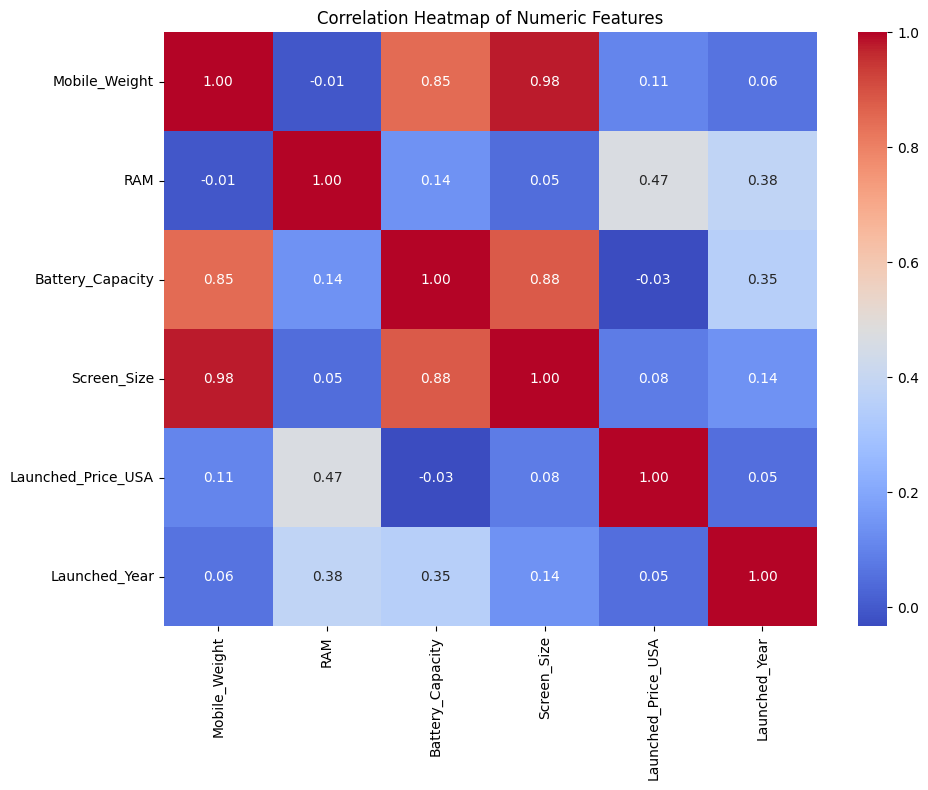

In [169]:
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

 There is a high positive correlation (0.98) between mobile weight and screen size, indicating that larger phones tend to be heavier. Similarly, battery capacity is strongly correlated with both screen size (0.88) and weight (0.85), which makes sense since larger devices can house bigger batteries. These strong inter-feature correlations suggest multicollinearity — meaning some features provide overlapping information. While this is not a major issue for tree-based models like Random Forest, it can impact linear models and should be considered when selecting features.

Create a scatter plot to visualize how phone prices change with RAM size

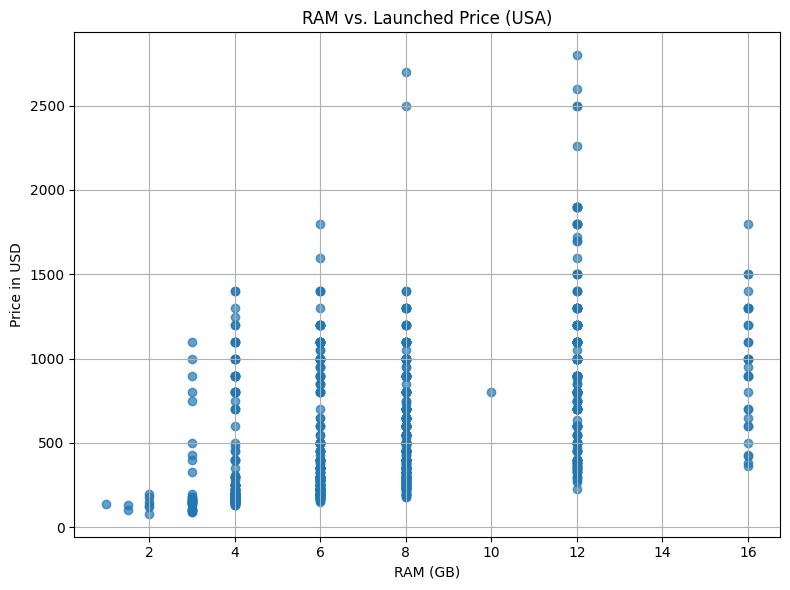

In [170]:
plt.figure(figsize=(8, 6))

plt.scatter(df['RAM'], df['Launched_Price_USA'], alpha=0.7)
plt.xlabel('RAM (GB)')
plt.ylabel('Price in USD')
plt.title('RAM vs. Launched Price (USA)')
plt.grid(True)
plt.tight_layout()
plt.show()

As RAM increases within this range, prices generally rise. This supports the idea that RAM is a useful predictor of price in mainstream models. However, the relationship becomes less consistent beyond 12 GB.

Create a styled bar plot showing the median launch price in USD for each phone brand.Helps compare typical pricing across brands and spot which companies offer more premium or budget-friendly devices.

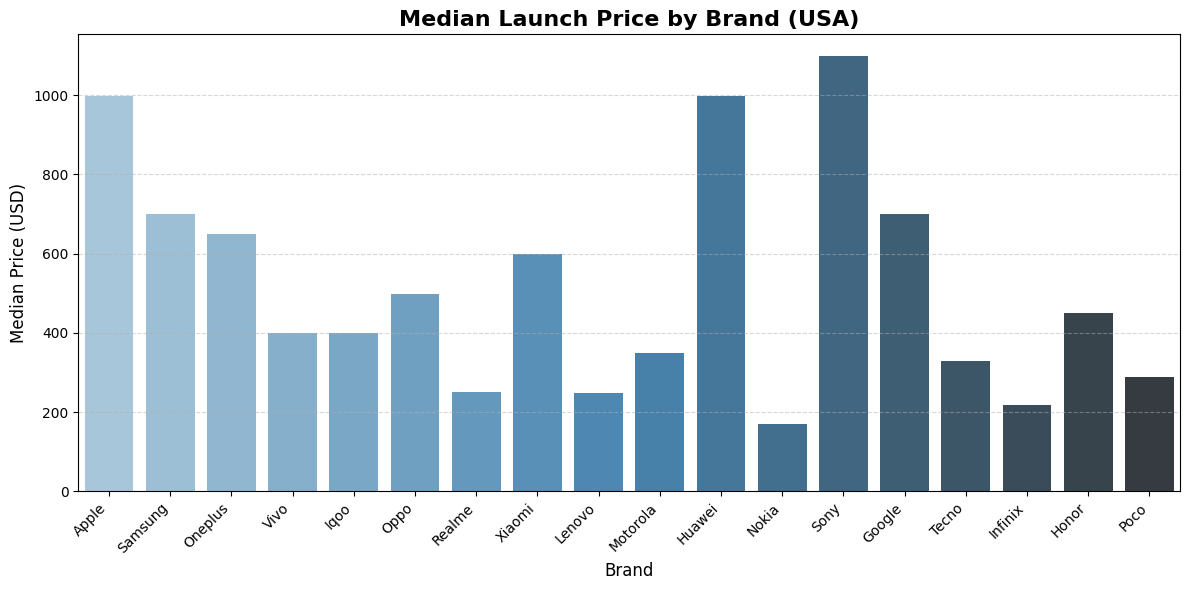

In [171]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Company_Name',
    y='Launched_Price_USA',
    data=df,
    estimator='median',
    ci=None,
    palette='Blues_d'
)

plt.title('Median Launch Price by Brand (USA)', fontsize=16, fontweight='bold')
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Median Price (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


The chart shows that Apple, Sony, and Huawei have the highest median phone prices, suggesting they mostly sell premium devices. Samsung, Google, and OnePlus follow as upper-mid-range brands. In contrast, brands like Infinix, Tecno, Nokia, Poco, and Realme offer more budget-friendly phones, with much lower median prices. This pricing trend helps us understand how different companies position their phones in the market and shows that brand is an important factor when predicting phone prices.

Creat lineplot of the battery size trend over the years

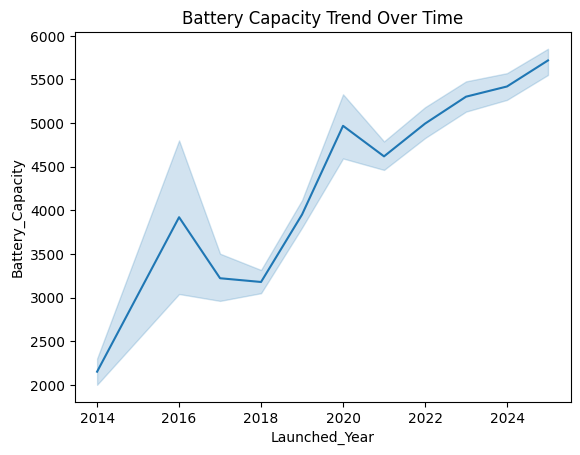

In [172]:
sns.lineplot(x='Launched_Year', y='Battery_Capacity', data=df)
plt.title('Battery Capacity Trend Over Time');

The graph shows a clear upward trend in battery capacity from 2014 to 2025. While there were a few dips around 2016-2018, overall, smartphone batteries have significantly increased in size over the years.

Plot a histogram with value labels to show how many phones fall into each price range.

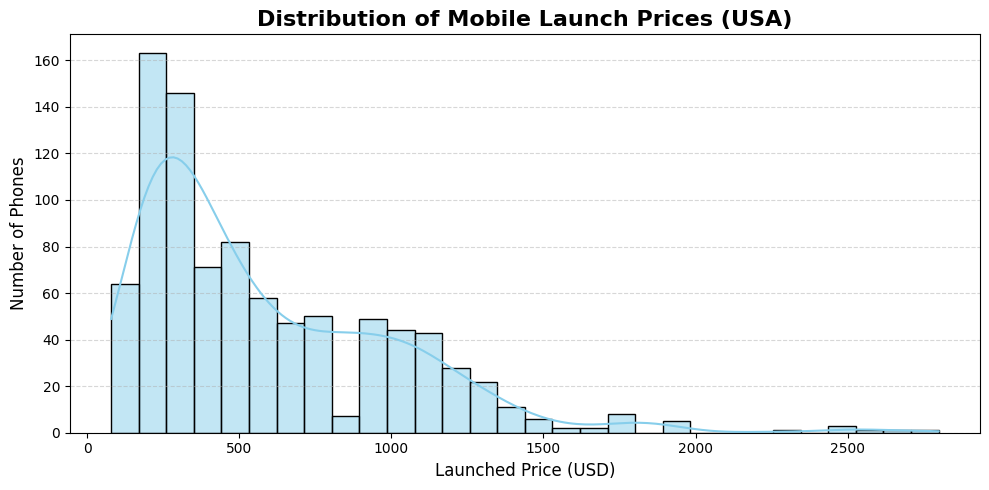

In [173]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='Launched_Price_USA',
    bins=30,
    kde=True,
    color='skyblue'
)

plt.title('Distribution of Mobile Launch Prices (USA)', fontsize=16, fontweight='bold')
plt.xlabel('Launched Price (USD)', fontsize=12)
plt.ylabel('Number of Phones', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


The chart shows that most mobile phones are launched at prices between 100 and 600 USD, with the largest number clustered around 200-300 USD. As the price increases, the number of phones decreases, creating a right-skewed distribution.

Define the input features and the target (launch price in the USA)

In [174]:
features = ['RAM', 'Battery_Capacity', 'Screen_Size', 'Mobile_Weight', 'Processor', 'Launched_Year', 'Model_Name']
target = 'Launched_Price_USA'

Filter and drop missing values

In [175]:
df_model = df[features + [target]].dropna()

One-hot encode categorical variables

In [176]:
df_encoded = pd.get_dummies(df_model, columns=['Processor', 'Model_Name'], drop_first=True)


Train a Random Forest model to predict phone launch prices using cleaned and encoded features, evaluate its accuracy with MAE and R², and make a sample prediction for one test device.And make a sample prediction — 20% of the data is used for testing (to evaluate model accuracy), and 80% for training.

In [177]:
X = df_encoded.drop(columns=[target])
y = df_encoded[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Random Forest - Mean Absolute Error: ${mae:.2f}")
print(f"Random Forest - R² Score: {r2:.2f}")

sample = X_test.iloc[[0]]
predicted_price = rf.predict(sample)[0]
print(f"Predicted Price for New Device: ${predicted_price:.2f}")


Random Forest - Mean Absolute Error: $105.78
Random Forest - R² Score: 0.84
Predicted Price for New Device: $680.20


The Random Forest model works well, with an R² score of 0.84, meaning it explains 84% of the variation in phone prices. The average error is about 105.78 USD, which shows the predictions are generally close to actual prices. The model is especially accurate for phones under 1000 USD, where most of the data is. For example, it predicted the price of one test phone as 680.20 USD, which is a realistic and reasonable estimate. Overall, the model gives good results and is reliable for predicting most phone prices.

Create an interactive Bokeh scatter plot to compare Actual vs. Predicted phone prices using the test set — includes hover tooltips, zoom features, and a red dashed reference line (y = x) to visually assess model accuracy.

In [178]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.io import output_notebook

output_notebook()
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

source = ColumnDataSource(results)
p = figure(
    title="Actual vs Predicted Launch Prices (USA)",
    x_axis_label="Actual Price (USD)",
    y_axis_label="Predicted Price (USD)",
    width=700,
    height=500,
    tools="pan,box_zoom,reset,save"
)
p.circle('Actual', 'Predicted', source=source, size=8, alpha=0.6)
hover = HoverTool(tooltips=[
    ("Actual", "@Actual{0.00}"),
    ("Predicted", "@Predicted{0.00}")
])
p.add_tools(hover)

p.line(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()],
       color='red', line_dash='dashed', legend_label="Perfect Prediction")

p.legend.location = "top_left"
p.title.text_font_size = '16pt'
p.xaxis.axis_label_text_font_size = "12pt"
p.yaxis.axis_label_text_font_size = "12pt"

show(p)


The model shows strong predictive performance overall, especially for low- to mid-range phones, which make up the majority of the dataset. The accuracy is highest below 1000 USD, where predictions closely follow the ideal diagonal line. However, for high-end phones above 1500 USD, the predictions are less consistent, likely due to fewer examples or more complex pricing factors not captured by features like RAM or battery alone. The visualization confirms that the Random Forest model is well-suited for general pricing but could be improved for luxury segment predictions, possibly by including brand strength or additional features.